In [6]:
import pandas as pd

# read file (IMPORTANT: sep=';')
data = pd.read_csv("student-mat (1) (1).csv", sep=',')

# clean column names
data.columns = data.columns.str.strip()
print(data.columns.tolist())

# select required columns
data = data[['studytime','failures','G3']]
print(data.head())


['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
   studytime  failures  G3
0          2         0   6
1          2         0   6
2          2         3  10
3          3         0  15
4          2         0  10


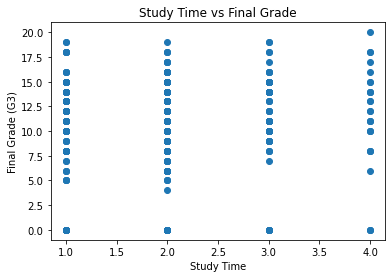

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(data['studytime'], data['G3'])

plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Final Grade")

plt.show()

In [8]:
x =data[['studytime','failures']]
y =data['G3']

The linear regression model predicts the student's final exam score (G3) based on study time and number of past failures.

For the input (studytime = 3, failures = 1), the predicted mark is approximately 9.15.

This shows that the model learns the relationship between study habits and performance

Linear Regression: [9.15412477]


<Figure size 576x360 with 0 Axes>

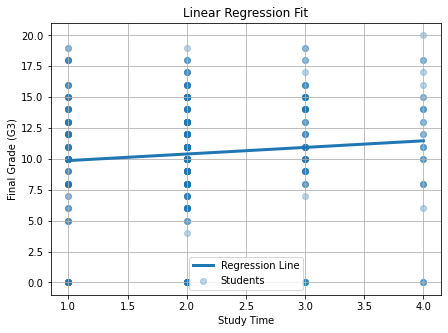

In [14]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Train model
lr = LinearRegression()
lr.fit(x, y)

# Prediction
prediction = lr.predict([[3, 1]])
print("Linear Regression:", prediction)

# Visualization
plt.figure(figsize=(8,5))

import numpy as np
import matplotlib.pyplot as plt

# Use only studytime for visualization
x1 = data[['studytime']]
y1 = data['G3']

lr.fit(x1, y1)

x_line = np.array([1, 2, 3, 4]).reshape(-1,1)
y_line = lr.predict(x_line)

plt.figure(figsize=(7,5))

plt.scatter(data['studytime'],
            data['G3'],
            alpha=0.3,
            label='Students')

plt.plot(x_line,
         y_line,
         linewidth=3,
         label='Regression Line')

plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)

plt.show()



The logistic regression model classifies student performance into pass or fail based on a threshold of 10 marks.

For the input (studytime = 3, failures = 1), the model predicts False, meaning the student is likely to fail.

This aligns with the linear regression prediction of approximately 9.15 marks.

Prediction for Study Time = 3 and Failures = 1: [False]


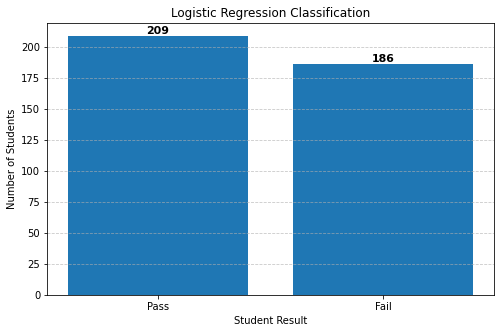

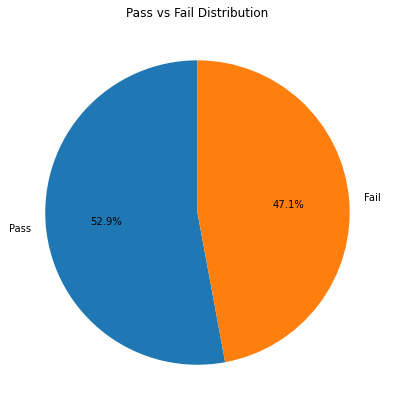

In [16]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Create Pass/Fail column
data['result'] = data['G3'] > 10

# Input and Output
X_log = data[['studytime', 'failures']]
y_log = data['result']

# Train Logistic Regression Model
log = LogisticRegression()
log.fit(X_log, y_log)

# Prediction
prediction = log.predict([[3, 1]])
print("Prediction for Study Time = 3 and Failures = 1:", prediction)

# Count Pass and Fail Students
result_count = data['result'].value_counts()

pass_count = result_count.get(True, 0)
fail_count = result_count.get(False, 0)

# -------------------------
# BAR CHART
# -------------------------
plt.figure(figsize=(8,5))

bars = plt.bar(
    ['Pass', 'Fail'],
    [pass_count, fail_count]
)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(int(height)),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.xlabel("Student Result")
plt.ylabel("Number of Students")
plt.title("Logistic Regression Classification")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# -------------------------
# PIE CHART
# -------------------------
plt.figure(figsize=(7,7))

plt.pie(
    [pass_count, fail_count],
    labels=['Pass', 'Fail'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Pass vs Fail Distribution")

plt.show()

Logistic Regression is used to classify students as Pass or Fail based on study time and failures.

The bar chart shows the number of students classified into each category, while the pie chart shows the percentage distribution of Pass and Fail students